In [1]:
!pip install scikit-image pydicom opencv-python

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from skimage.transform import resize
import matplotlib.pyplot as plt
import pydicom
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# Dataset paths (adjust as needed)
dataset_path = "../input/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/"
train_images_dir = os.path.join(dataset_path, "stage_2_train/")
train_csv = os.path.join(dataset_path, "stage_2_train.csv")

# Load and preprocess train.csv
df = pd.read_csv(train_csv)

# Create 'id' and 'subtype' columns. For example, "ID_12345_epidural" -> id: "ID_12345", subtype: "epidural"
df['id'] = df['ID'].apply(lambda st: "ID_" + st.split('_')[1])
df['subtype'] = df['ID'].apply(lambda st: st.split('_')[2])
df = df[["id", "subtype", "Label"]]

# Remove duplicates and fill missing labels
df = df.drop_duplicates(subset=['id', 'subtype'])
df['Label'] = df['Label'].fillna(0)

# Pivot the data so that each row is a unique image and columns are subtypes
df_pivot = df.pivot(index='id', columns='subtype', values='Label').reset_index()
print("Pivoted DataFrame shape:", df_pivot.shape)
print(df_pivot.head())

# Add file paths for each image
df_pivot['file_path'] = df_pivot['id'].apply(lambda x: os.path.join(train_images_dir, f"{x}.dcm"))

df_subset = df_pivot.sample(n=2000, random_state=42)
print(f"Using {len(df_subset)} samples for training.")

# Preprocess DICOM images
def preprocess_dicom(file_path, label, target_size=(224, 224)):
    try:
        dicom = pydicom.dcmread(file_path)
        img = dicom.pixel_array
        img = resize(img, target_size, mode="constant", anti_aliasing=True)
        img = np.expand_dims(img, axis=-1)  # Add channel dimension
        img = np.repeat(img, 3, axis=-1)    # Convert grayscale to RGB
        img = img / np.max(img) #if np.max(img) > 0 else img
        return img, label
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None, None

#image-label pairs
images_list, labels_list = [], []
for _, row in df_subset.iterrows():
    img, lbl = preprocess_dicom(
        row['file_path'],
        row[["epidural", "intraparenchymal", "intraventricular", "subarachnoid", "subdural","any"]].values
    )
    if img is not None:
        images_list.append(img)
        labels_list.append(lbl)

#convert to array
images = np.array(images_list)
labels = np.array(labels_list)
print("Preprocessed images shape:", images.shape)
print("Preprocessed labels shape:", labels.shape)

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(images, labels, test_size=0.2, random_state=42)

y_train = np.array(y_train, dtype=np.float32)
y_val = np.array(y_val, dtype=np.float32)
#y_train = y_train.astype(np.float32)
#y_val = y_val.astype(np.float32)
#print("X_train shape:", X_train.shape)
#print("y_train shape:", y_train.shape) 

# Define the ResNet50 model
def create_resnet50_model(input_shape=(224, 224, 3), num_classes=6):
    base_model = ResNet50(weights="imagenet", include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze base model
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(num_classes, activation="sigmoid")   #identify multi-labels
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model

# Create and train the model
resnet_model = create_resnet50_model()

#Save the model
resnet_model.save('resnet_model.h5')

history = resnet_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=3, batch_size=32)

# Check data shapes and types
print("X_train shape:", X_train.shape, "dtype:", X_train.dtype)
print("y_train shape:", y_train.shape, "dtype:", y_train.dtype)
print("X_val shape:", X_val.shape, "dtype:", X_val.dtype)
print("y_val shape:", y_val.shape, "dtype:", y_val.dtype)


# Evaluate the model
resnet_y_pred = resnet_model.predict(X_val)
resnet_y_pred_binary = (resnet_y_pred > 0.5).astype(int)

2025-04-30 13:22:22.200731: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746019342.441149      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746019342.513418      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Pivoted DataFrame shape: (752803, 7)
subtype            id  any  epidural  intraparenchymal  intraventricular  \
0        ID_000012eaf    0         0                 0                 0   
1        ID_000039fa0    0         0                 0                 0   
2        ID_00005679d    0         0                 0                 0   
3        ID_00008ce3c    0         0                 0                 0   
4        ID_0000950d7    0         0                 0                 0   

subtype  subarachnoid  subdural  
0                   0         0  
1                   0         0  
2                   0         0  
3                   0         0  
4                   0         0  
Using 2000 samples for training.
Preprocessed images shape: (2000, 224, 224, 3)
Preprocessed labels shape: (2000, 6)


2025-04-30 13:23:58.616539: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 183s 3s/step - accuracy: 0.0933 - loss: 0.7713 - val_accuracy: 0.0000e+00 - val_loss: 0.3322
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 183s 3s/step - accuracy: 0.0532 - loss: 0.3527 - val_accuracy: 0.0000e+00 - val_loss: 0.2399
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - accuracy: 0.0511 - loss: 0.2668 - val_accuracy: 0.0000e+00 - val_loss: 0.2287
X_train shape: (1600, 224, 224, 3) dtype: float64
y_train shape: (1600, 6) dtype: float32
X_val shape: (400, 224, 224, 3) dtype: float64
y_val shape: (400, 6) dtype: float32
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step


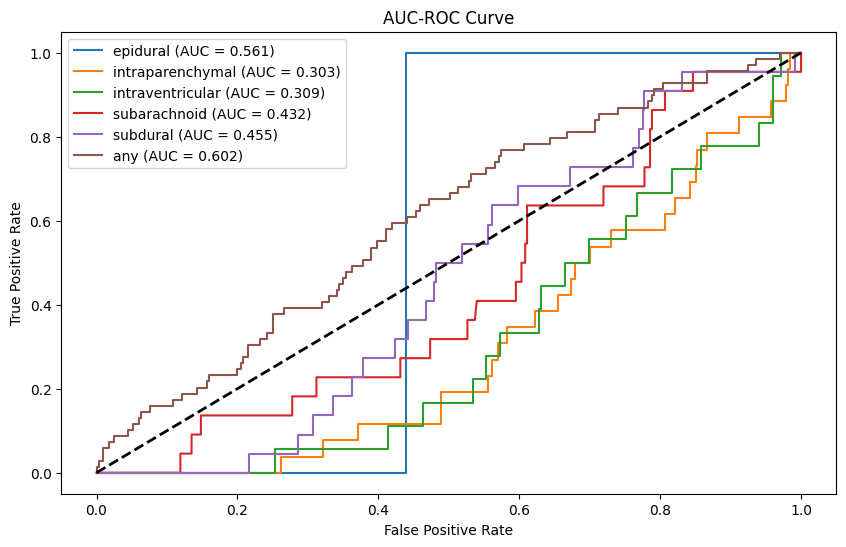

In [2]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 6))

for i, label in enumerate(["epidural", "intraparenchymal", "intraventricular", "subarachnoid", "subdural", "any"]):
    fpr, tpr, _ = roc_curve(y_val[:, i], resnet_y_pred[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal reference line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve")
plt.legend()
plt.show()

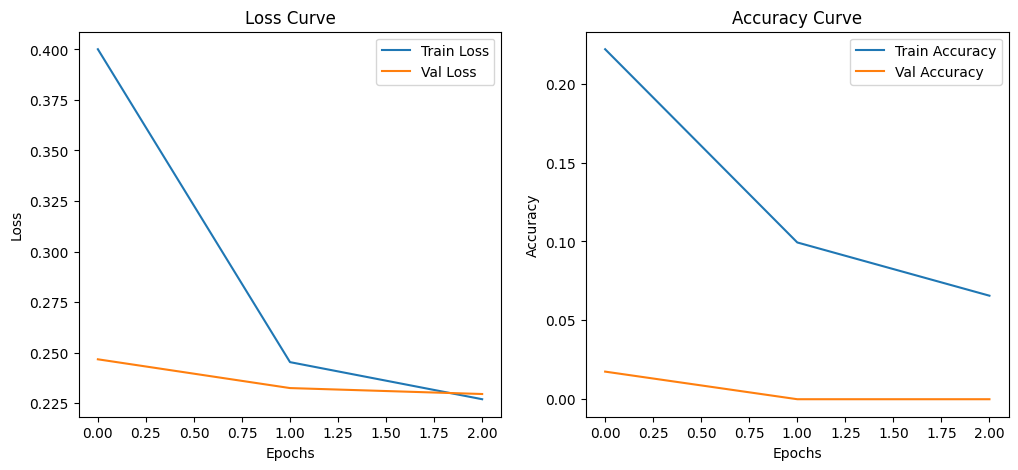

In [3]:
# Plot training & validation loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Plot training & validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.show()

In [4]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score
from sklearn.metrics import classification_report

accuracy = accuracy_score(y_val, resnet_y_pred_binary)

class_labels = ["epidural", "intraparenchymal", "intraventricular", "subarachnoid", "subdural", "any"]
report = classification_report(y_val, resnet_y_pred_binary, target_names=class_labels)
print(report)

# Sensitivity (Recall per class) with safe division
resnet_conf_matrix = confusion_matrix(y_val.argmax(axis=1), resnet_y_pred_binary.argmax(axis=1))
resnet_sensitivity = np.divide(
    np.diag(resnet_conf_matrix),
    np.sum(resnet_conf_matrix, axis=1),
    out=np.zeros_like(np.diag(resnet_conf_matrix), dtype=np.float32),
    where=np.sum(resnet_conf_matrix, axis=1) != 0
)

# Training Accuracy (Fixed)
resnet_accuracy = history.history['accuracy'][-1]

# Print metrics
print(f"ResNet50V2 Accuracy: {accuracy:.4f}")
print(f"ResNet50V2 Training Accuracy: {resnet_accuracy:.4f}")
print(f"ResNet50V2 Training Loss: {history.history['loss'][-1]:.4f}")
print(f"ResNet50V2 Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"ResNet50V2 Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"ResNet50V2 Sensitivity (per class): {resnet_sensitivity}")

                  precision    recall  f1-score   support

        epidural       0.00      0.00      0.00         1
intraparenchymal       0.00      0.00      0.00        26
intraventricular       0.00      0.00      0.00        18
    subarachnoid       0.00      0.00      0.00        22
        subdural       0.00      0.00      0.00        22
             any       0.00      0.00      0.00        69

       micro avg       0.00      0.00      0.00       158
       macro avg       0.00      0.00      0.00       158
    weighted avg       0.00      0.00      0.00       158
     samples avg       0.00      0.00      0.00       158

ResNet50V2 Accuracy: 0.8275
ResNet50V2 Training Accuracy: 0.0656
ResNet50V2 Training Loss: 0.2269
ResNet50V2 Validation Accuracy: 0.0000
ResNet50V2 Validation Loss: 0.2295
ResNet50V2 Sensitivity (per class): [1. 0. 0. 0. 0.]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
epidural: Hemorrhage Detected (0.71)
intraparenchymal: Hemorrhage Detected (0.85)
intraventricular: No Hemorrhage (0.32)
subarachnoid: No Hemorrhage (0.15)
subdural: No Hemorrhage (0.25)
any: No Hemorrhage (0.11)


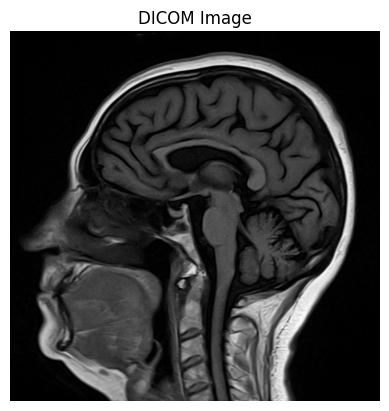

In [7]:
import numpy as np
import pydicom
import os
import tensorflow as tf
from skimage.transform import resize
import matplotlib.pyplot as plt

# Load trained model
model = tf.keras.models.load_model("resnet_model.h5")

# Define image path
image_path = "/kaggle/input/images/1-1.dcm"

def preprocess_dicom(file_path, target_size=(224, 224)):
    try:
        dicom = pydicom.dcmread(file_path)
        img = dicom.pixel_array
        img = resize(img, target_size, mode="constant", anti_aliasing=True)
        img = np.expand_dims(img, axis=-1)  # Add channel dimension
        img = np.repeat(img, 3, axis=-1)    # Convert grayscale to RGB
        img = img / np.max(img) if np.max(img) > 0 else img  # Normalize
        return np.expand_dims(img, axis=0)  # Add batch dimension
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Preprocess the image
image = preprocess_dicom(image_path)
if image is not None:
    # Predict
    predictions = model.predict(image)[0]
    
    # Define hemorrhage subtypes
    hemorrhage_types = ["epidural", "intraparenchymal", "intraventricular", "subarachnoid", "subdural", "any"]
    
    # Print predictions
    for hemorrhage, prob in zip(hemorrhage_types, predictions):
        print(f"{hemorrhage}: {'Hemorrhage Detected' if prob > 0.5 else 'No Hemorrhage'} ({prob:.2f})")
    
    # Display image
    dicom = pydicom.dcmread(image_path)
    plt.imshow(dicom.pixel_array, cmap='gray')
    plt.title("DICOM Image")
    plt.axis("off")
    plt.show()
else:
    print("Failed to process the image.")